In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
from roofline import TransformerRoofline
from cost import CostEst

*******List_Timebreakdown*******
Model   Hardware            Ratio_P Batch  Max_Token Sparse    Comp-P    Arith-P   Time-P    Util-P    Comp-GP   Arith-P   Time-GP   Util-GP   Comp-GA   Arith-P   Time-GA   Util-GA   Comp-Ttl    Time-Ttl  Util-Ttl  Token/Sec 
GPT3.5  1                   0.25    32     8192      default   244091.58 72323.43  97.79     1.0000    712483.53 34.36     1296.00   0.2203    49478.02  1.07      2880.00   0.0069    1006053.14  4273.79   NA        479.20    
*******List_Timebreakdown*******
Model   Hardware            Ratio_P Batch  Max_Token Sparse    Comp-P    Arith-P   Time-P    Util-P    Comp-GP   Arith-P   Time-GP   Util-GP   Comp-GA   Arith-P   Time-GA   Util-GA   Comp-Ttl    Time-Ttl  Util-Ttl  Token/Sec 
GPT3.5  1                   0.25    32     8192      default   244091.58 72323.43  97.79     1.0000    712483.53 34.36     1296.00   0.2203    49478.02  1.07      386.55    1.0000    1006053.14  1780.34   NA        1150.34   
*******List_Timebreakdown*****

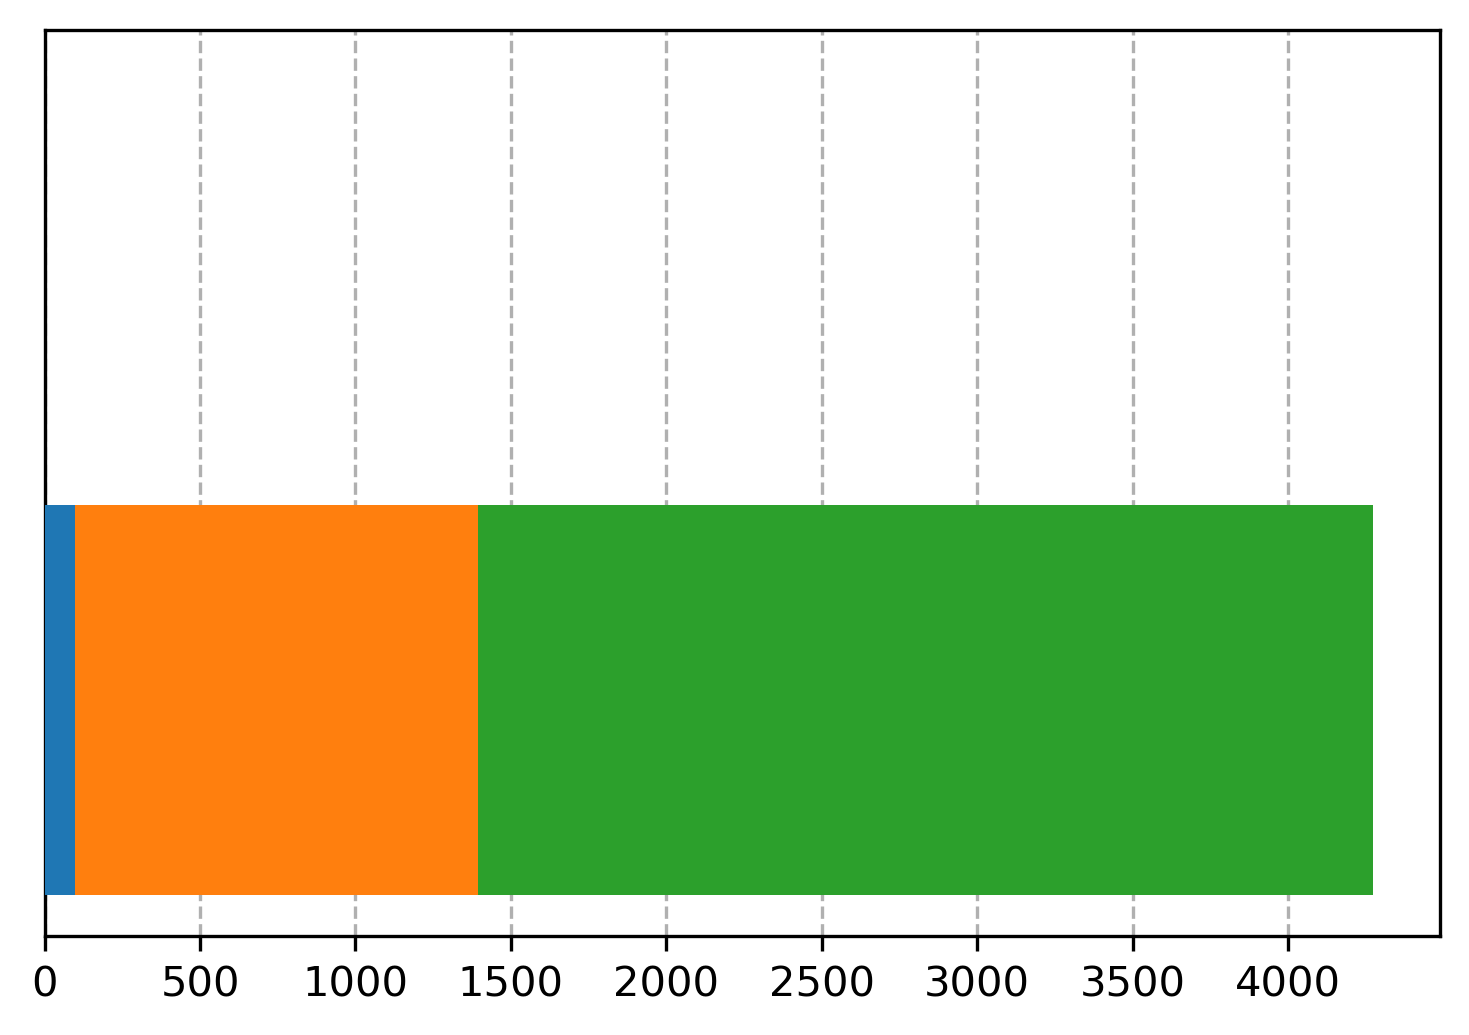

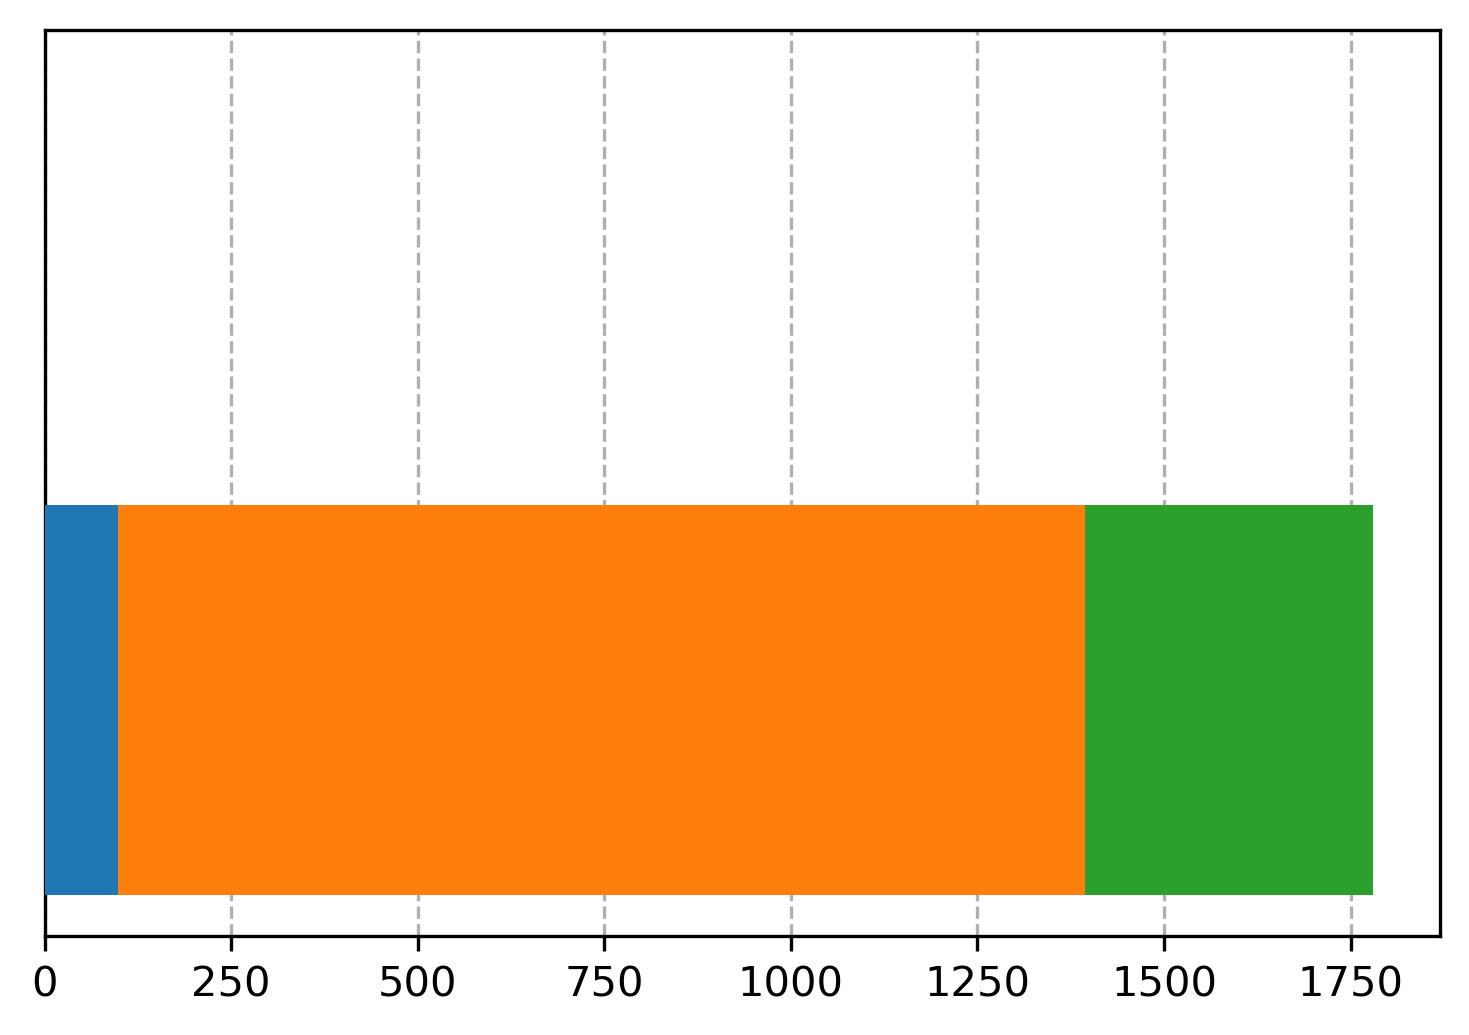

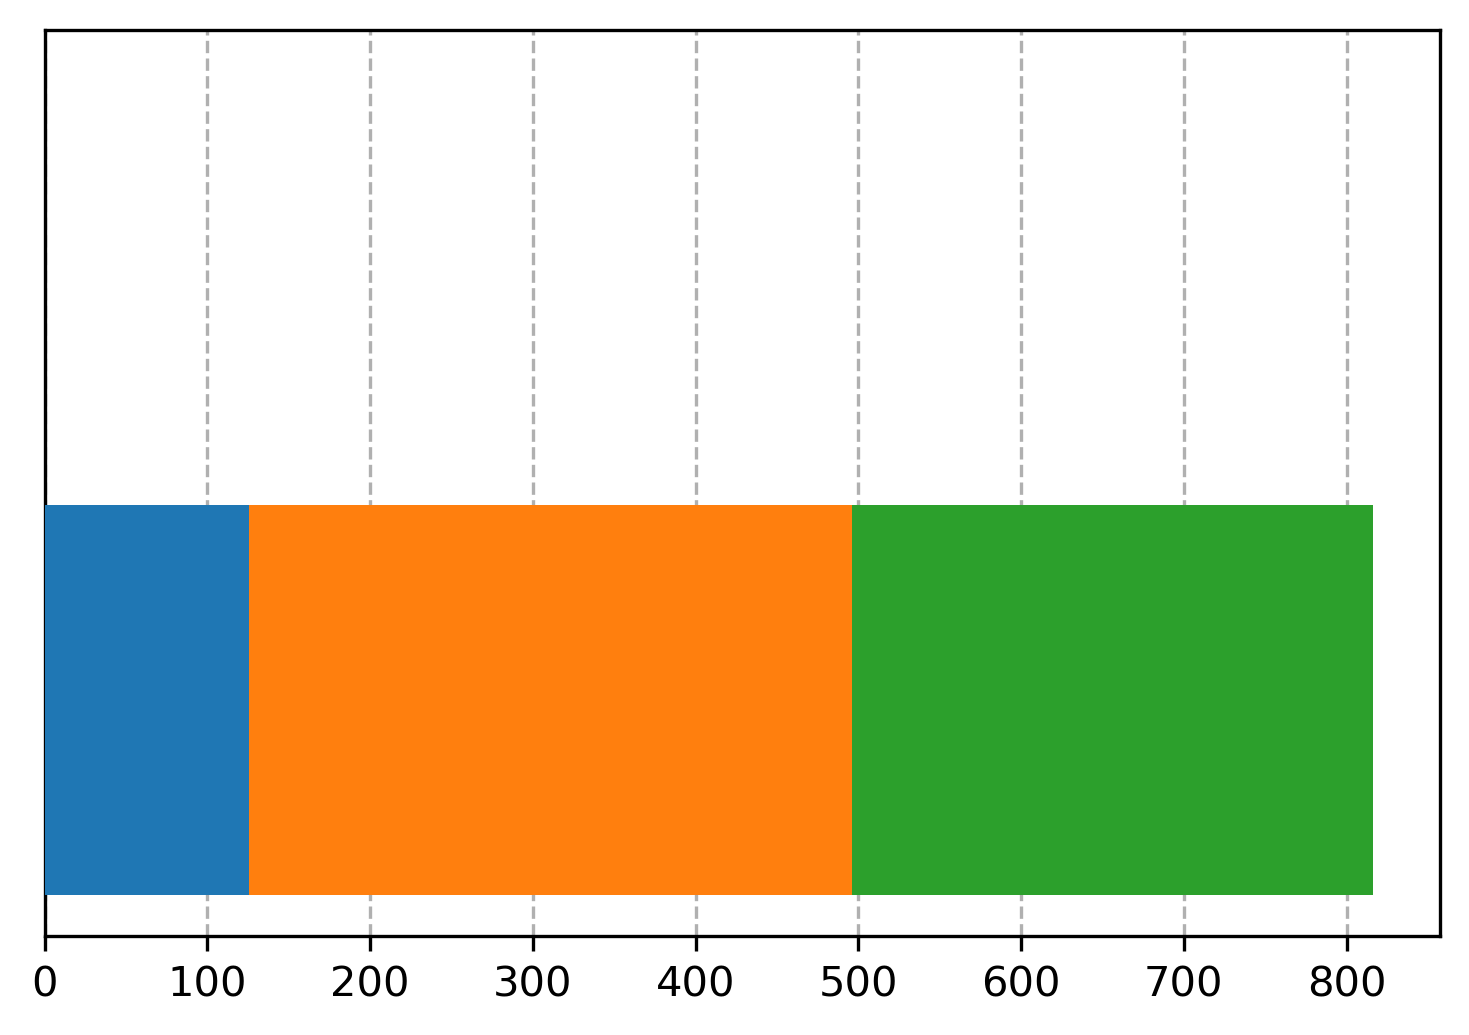

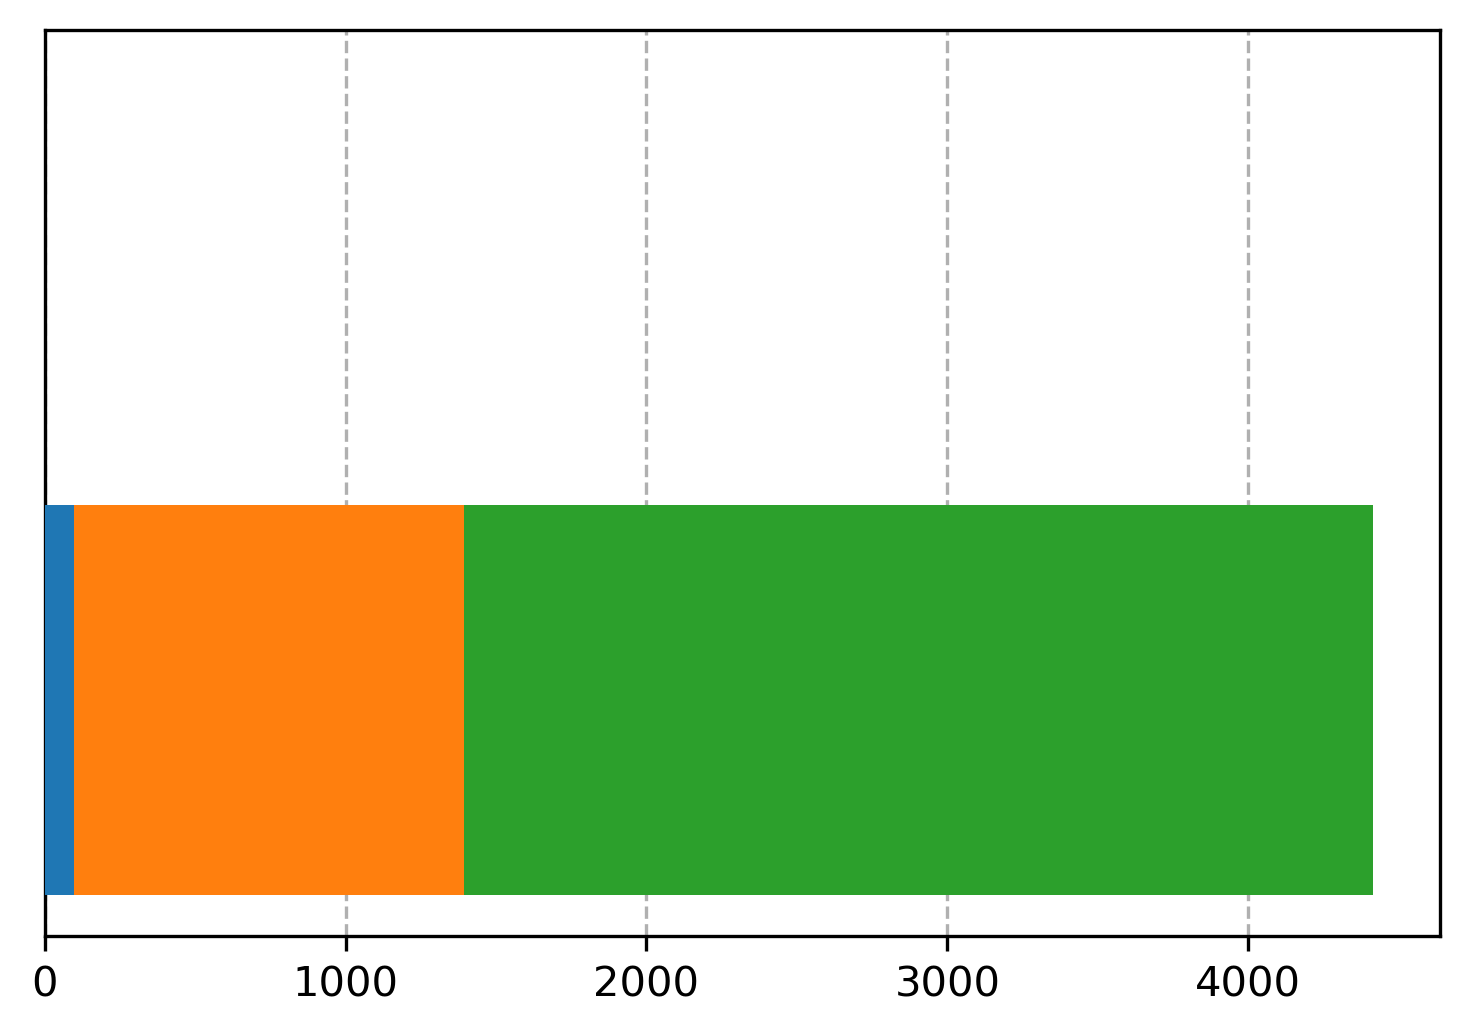

In [9]:
## Select 4 typical hardware for comparison
Require_Token_per_Second = 99000000
Hardware_Config = [
{# 8*A100
    "Config": "8*A100",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"A100", "quant":8}}],
    "Cost": {"A100":8, "Server": 1, "Rack_Unit": 4,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*A100 + 8*G6AiM
    "Config": "8*A100 + 8*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"G6AiM", "quant":8}}],
    "Cost": {"A100":8, "G6AiM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*A100 + 8*LPDDR4-PIM-DIMM
    "Config": "8*A100 + 8*LPDDR4-PIM-DIMM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"LPDDR4-PIM-DIMM", "quant":8}}],
    "Cost": {"A100":8, "LPDDR4-PIM-DIMM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*THRIVE2 + 8*LPDDR4-PIM-DIMM
    "Config": "8*THRIVE2 + 8*LPDDR4-PIM-DIMM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"THRIVE2", "quant":8}, "GNR-PRJ":{"hard":"THRIVE2", "quant":8}, "GNR-ACT":{"hard":"LPDDR4-PIM-DIMM", "quant":8}}],
    "Cost": {"THRIVE2":8, "LPDDR4-PIM-DIMM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
# {# 8*A100 + 853*SSD-PIM
#     "Config": "8*A100 + 853*SSD-PIM",
#     "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"SSD-PIM", "quant":853}}],
#     "Cost": {"A100":8, "SSD-PIM":853, "Server": 14, "Rack_Unit": 56,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
# }
]


roofline = TransformerRoofline('hardware_models.json')
cost_model = CostEst(hardware_json="hardware_elements.json")

for hw in Hardware_Config:
    roofline.Draw_Combination_Timebreakdown(Ratio_P=[0.25], Batchsize=[32], Max_Token=[8192], Model=["GPT3.5"], Comb_Hardware=hw["Roofline"], Sparse=["default"])
    hw["Cost"]["Token_per_Second"] = roofline.Token_per_Sec[0]

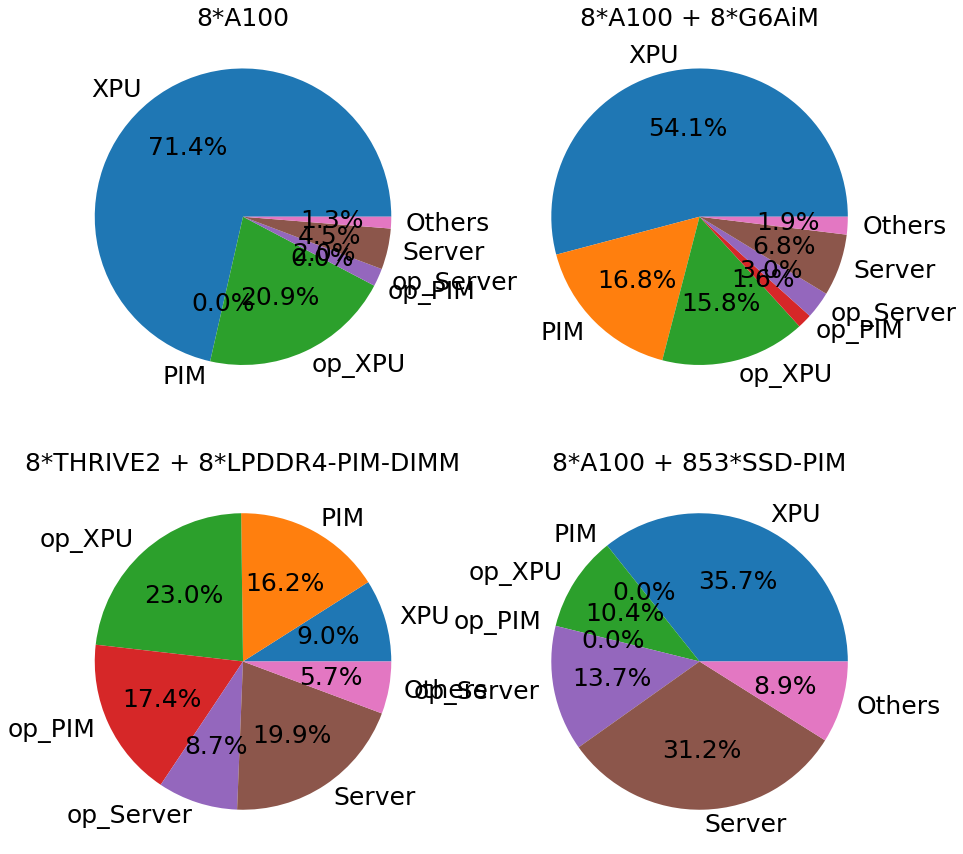

In [10]:
i = 1
plt.figure(figsize=(15,15))
for hw in Hardware_Config:
    cost_model.init_hardware(hardware_config=hw["Cost"])
    cost_model.cal_total_cost()
    if hw["Config"] == "8*A100":
        price_per_token_base = cost_model.price_per_token
    price = [
        cost_model.XPU_price, 
        cost_model.PIM_price, 
        cost_model.operation_price_XPU, 
        cost_model.operation_price_PIM, 
        cost_model.operation_price_server, 
        cost_model.server_total_price, 
        cost_model.datacenter_op_fee
    ]
    labels = ["XPU", "PIM", "op_XPU", "op_PIM", "op_Server", "Server", "Others"]
    plt.subplot(2,2,i)
    plt.pie(price, labels=labels, autopct="%1.1f%%", textprops={'fontsize':25})
    plt.title(hw["Config"], fontdict={'fontsize':25})
    i+=1
plt.show()


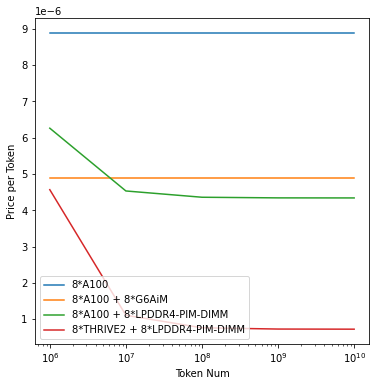

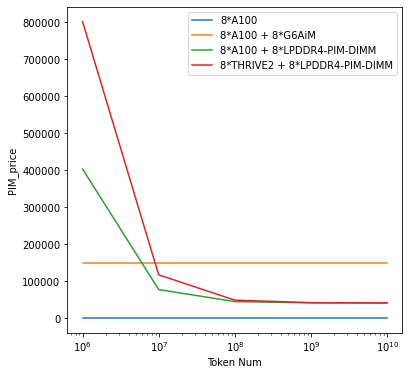

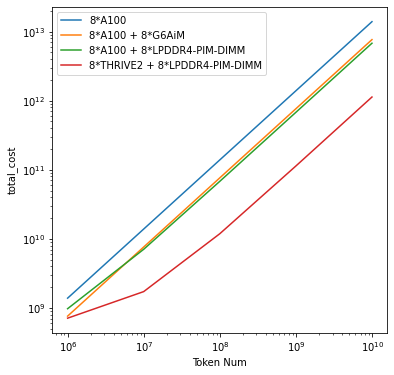

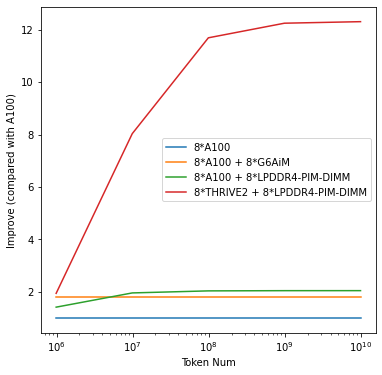

In [4]:
## Sensitivity: Require token per second
price_per_token = []
PIM_price = []
total_cost = []
ratio = []

Require_Token_per_Second = [990000, 9900000, 99000000, 990000000, 9900000000]
plt.figure(figsize=(6,6))
for hw in Hardware_Config:
    _price_per_token = []
    for req_token_sec in Require_Token_per_Second:
        hw["Cost"]["Require_Token_per_Second"] = req_token_sec
        cost_model = CostEst(hardware_json="hardware_elements.json")
        cost_model.init_hardware(hardware_config=hw["Cost"])
        cost_model.cal_total_cost()
        _price_per_token.append(cost_model.price_per_token)
    price_per_token.append(_price_per_token)
plt.plot(Require_Token_per_Second, price_per_token[0], label="8*A100")
plt.plot(Require_Token_per_Second, price_per_token[1], label="8*A100 + 8*G6AiM")
plt.plot(Require_Token_per_Second, price_per_token[2], label="8*A100 + 8*LPDDR4-PIM-DIMM")
plt.plot(Require_Token_per_Second, price_per_token[3], label="8*THRIVE2 + 8*LPDDR4-PIM-DIMM")
plt.legend()
plt.xscale('log')
plt.xlabel('Token Num')
plt.ylabel('Price per Token')
plt.show()


plt.figure(figsize=(6,6))
for hw in Hardware_Config:
    _PIM_price = []
    for req_token_sec in Require_Token_per_Second:
        hw["Cost"]["Require_Token_per_Second"] = req_token_sec
        cost_model = CostEst(hardware_json="hardware_elements.json")
        cost_model.init_hardware(hardware_config=hw["Cost"])
        cost_model.cal_total_cost()
        _PIM_price.append(cost_model.PIM_price)
    PIM_price.append(_PIM_price)
plt.plot(Require_Token_per_Second, PIM_price[0], label="8*A100")
plt.plot(Require_Token_per_Second, PIM_price[1], label="8*A100 + 8*G6AiM")
plt.plot(Require_Token_per_Second, PIM_price[2], label="8*A100 + 8*LPDDR4-PIM-DIMM")
plt.plot(Require_Token_per_Second, PIM_price[3], label="8*THRIVE2 + 8*LPDDR4-PIM-DIMM")
plt.legend()
plt.xscale('log')
plt.xlabel('Token Num')
plt.ylabel('PIM_price')
plt.show()

plt.figure(figsize=(6,6))
for hw in Hardware_Config:
    _total_cost = []
    for req_token_sec in Require_Token_per_Second:
        hw["Cost"]["Require_Token_per_Second"] = req_token_sec
        cost_model = CostEst(hardware_json="hardware_elements.json")
        cost_model.init_hardware(hardware_config=hw["Cost"])
        cost_model.cal_total_cost()
        _total_cost.append(cost_model.total_cost)
    total_cost.append(_total_cost)
plt.plot(Require_Token_per_Second, total_cost[0], label="8*A100")
plt.plot(Require_Token_per_Second, total_cost[1], label="8*A100 + 8*G6AiM")
plt.plot(Require_Token_per_Second, total_cost[2], label="8*A100 + 8*LPDDR4-PIM-DIMM")
plt.plot(Require_Token_per_Second, total_cost[3], label="8*THRIVE2 + 8*LPDDR4-PIM-DIMM")
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Token Num')
plt.ylabel('total_cost')
plt.show()

plt.figure(figsize=(6,6))
price_per_token = np.array(price_per_token)
plt.plot(Require_Token_per_Second, price_per_token[0]/price_per_token[0], label="8*A100")
plt.plot(Require_Token_per_Second, price_per_token[0]/price_per_token[1], label="8*A100 + 8*G6AiM")
plt.plot(Require_Token_per_Second, price_per_token[0]/price_per_token[2], label="8*A100 + 8*LPDDR4-PIM-DIMM")
plt.plot(Require_Token_per_Second, price_per_token[0]/price_per_token[3], label="8*THRIVE2 + 8*LPDDR4-PIM-DIMM")
plt.legend()
plt.xscale('log')
plt.xlabel('Token Num')
plt.ylabel('Improve (compared with A100)')
plt.show()

*******List_Timebreakdown*******
Model   Hardware            Ratio_P Batch  Max_Token Sparse    Comp-P    Arith-P   Time-P    Util-P    Comp-GP   Arith-P   Time-GP   Util-GP   Comp-GA   Arith-P   Time-GA   Util-GA   Comp-Ttl    Time-Ttl  Util-Ttl  Token/Sec 
GPT3.5  1                   0.25    10240  8192      default   78109306.0423143498.0931293.79  1.0000    227994731.1410995.12  91344.04  1.0000    15832967.441.07      921600.00 0.0069    321937004.611044237.84NA        627.60    
*******List_Timebreakdown*******
Model   Hardware            Ratio_P Batch  Max_Token Sparse    Comp-P    Arith-P   Time-P    Util-P    Comp-GP   Arith-P   Time-GP   Util-GP   Comp-GA   Arith-P   Time-GA   Util-GA   Comp-Ttl    Time-Ttl  Util-Ttl  Token/Sec 
GPT3.5  1                   0.25    10240  8192      default   78109306.0423143498.0931293.79  1.0000    227994731.1410995.12  91344.04  1.0000    15832967.441.07      123695.06 1.0000    321937004.61246332.89 NA        2660.46   
*******List_Timebrea

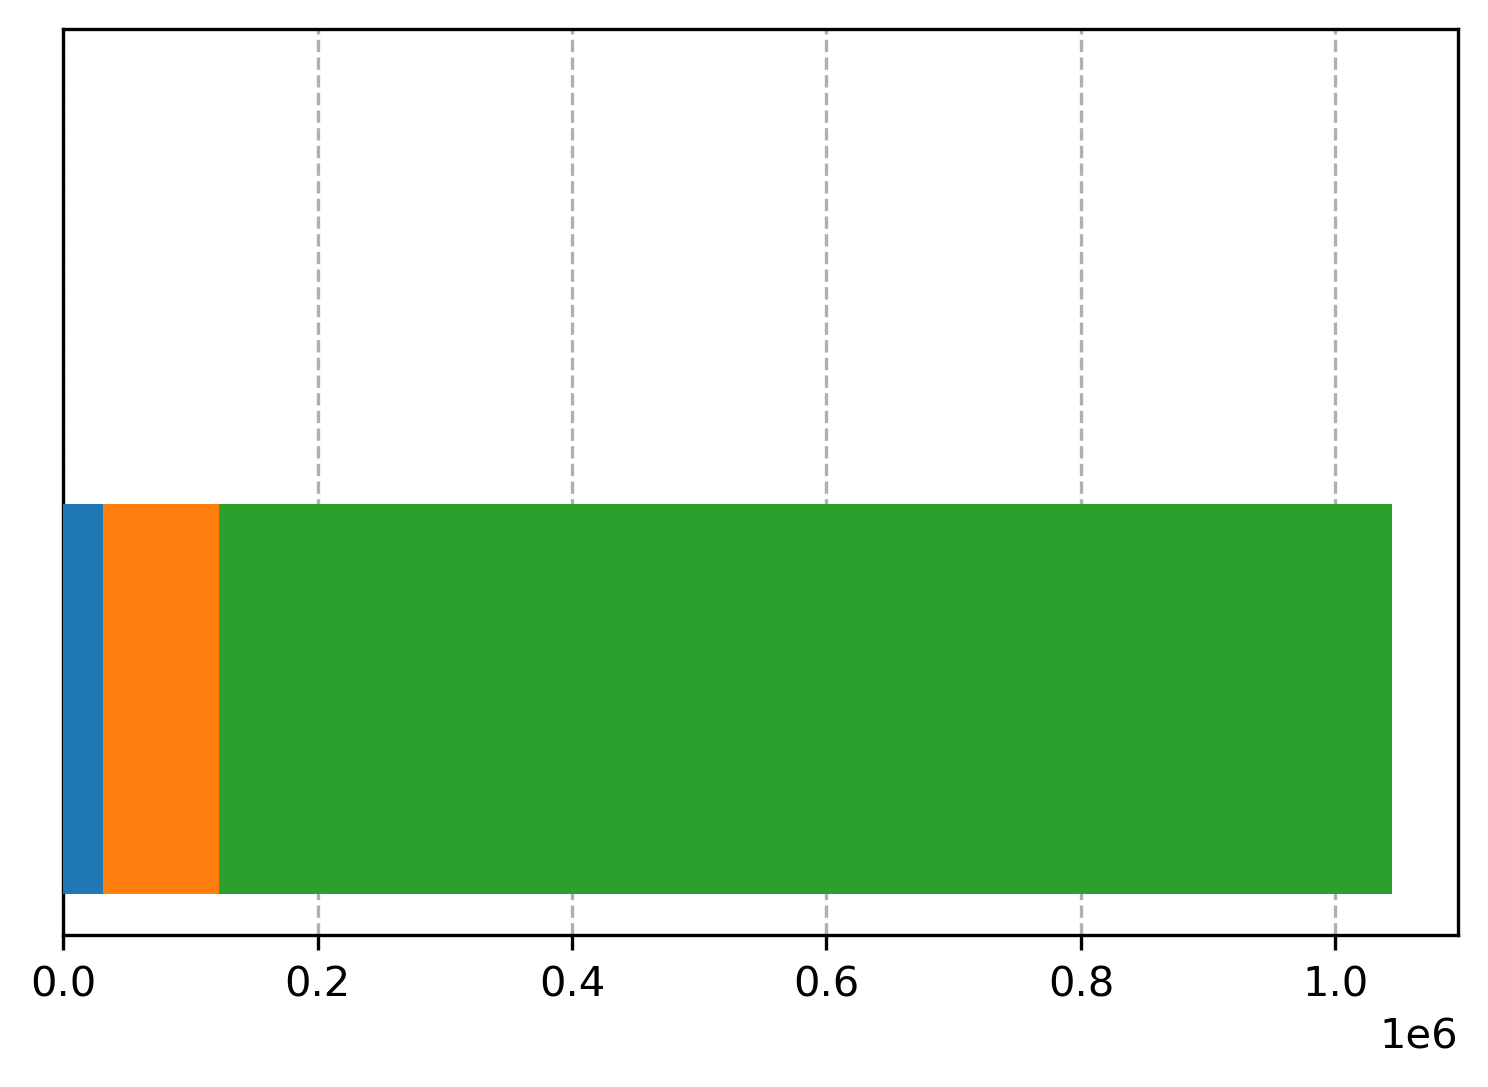

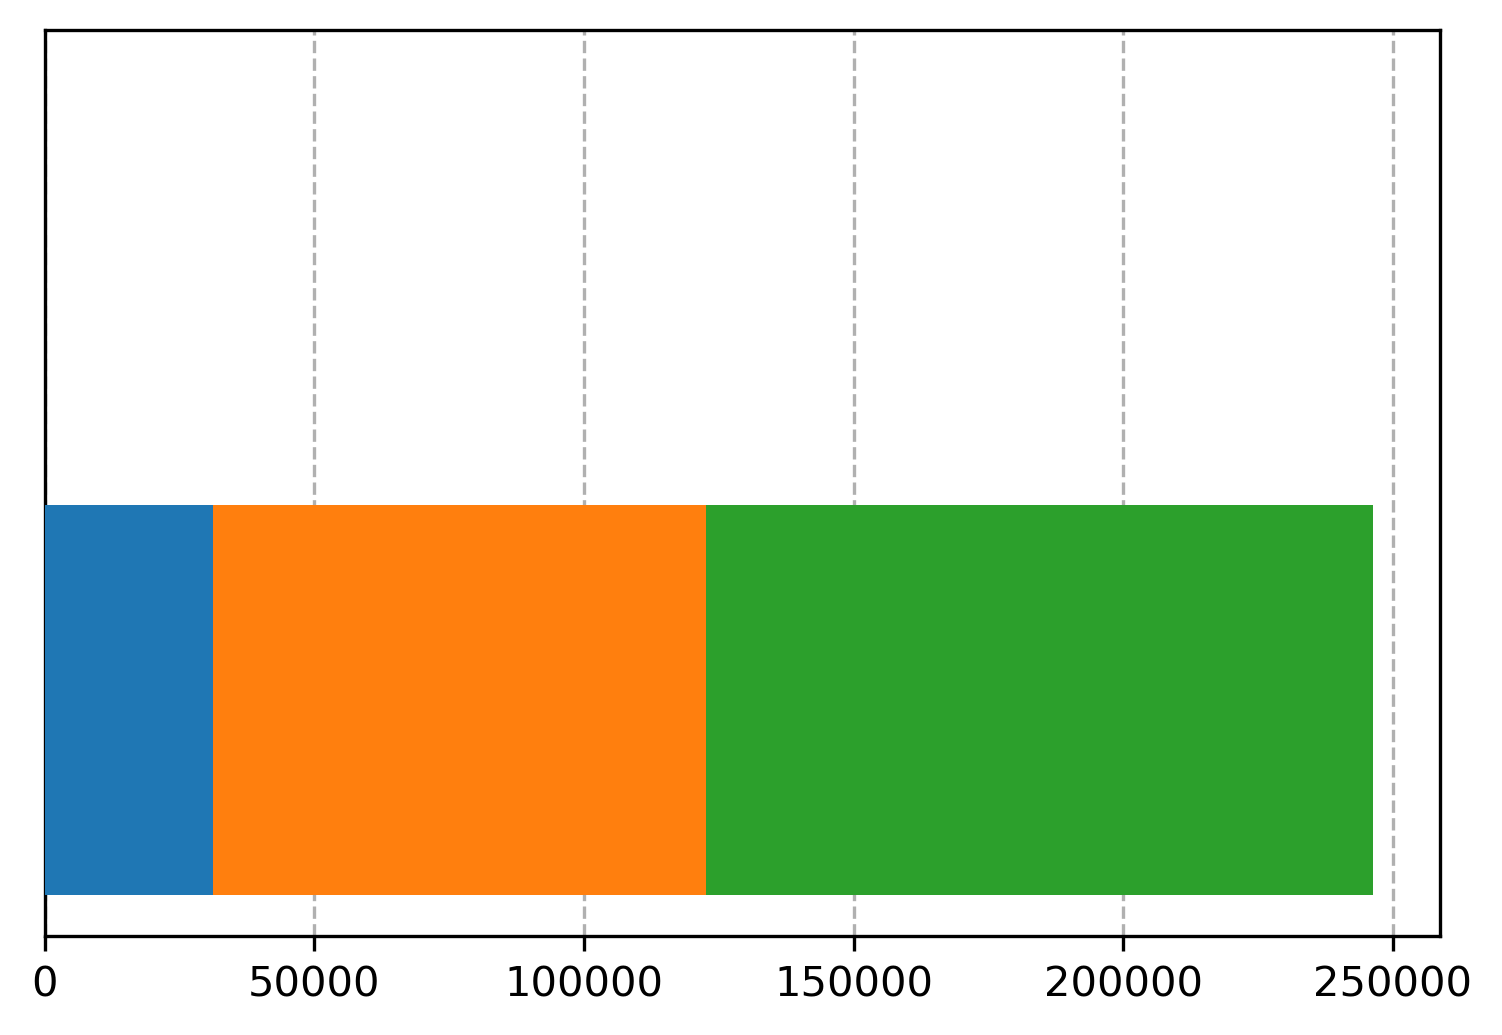

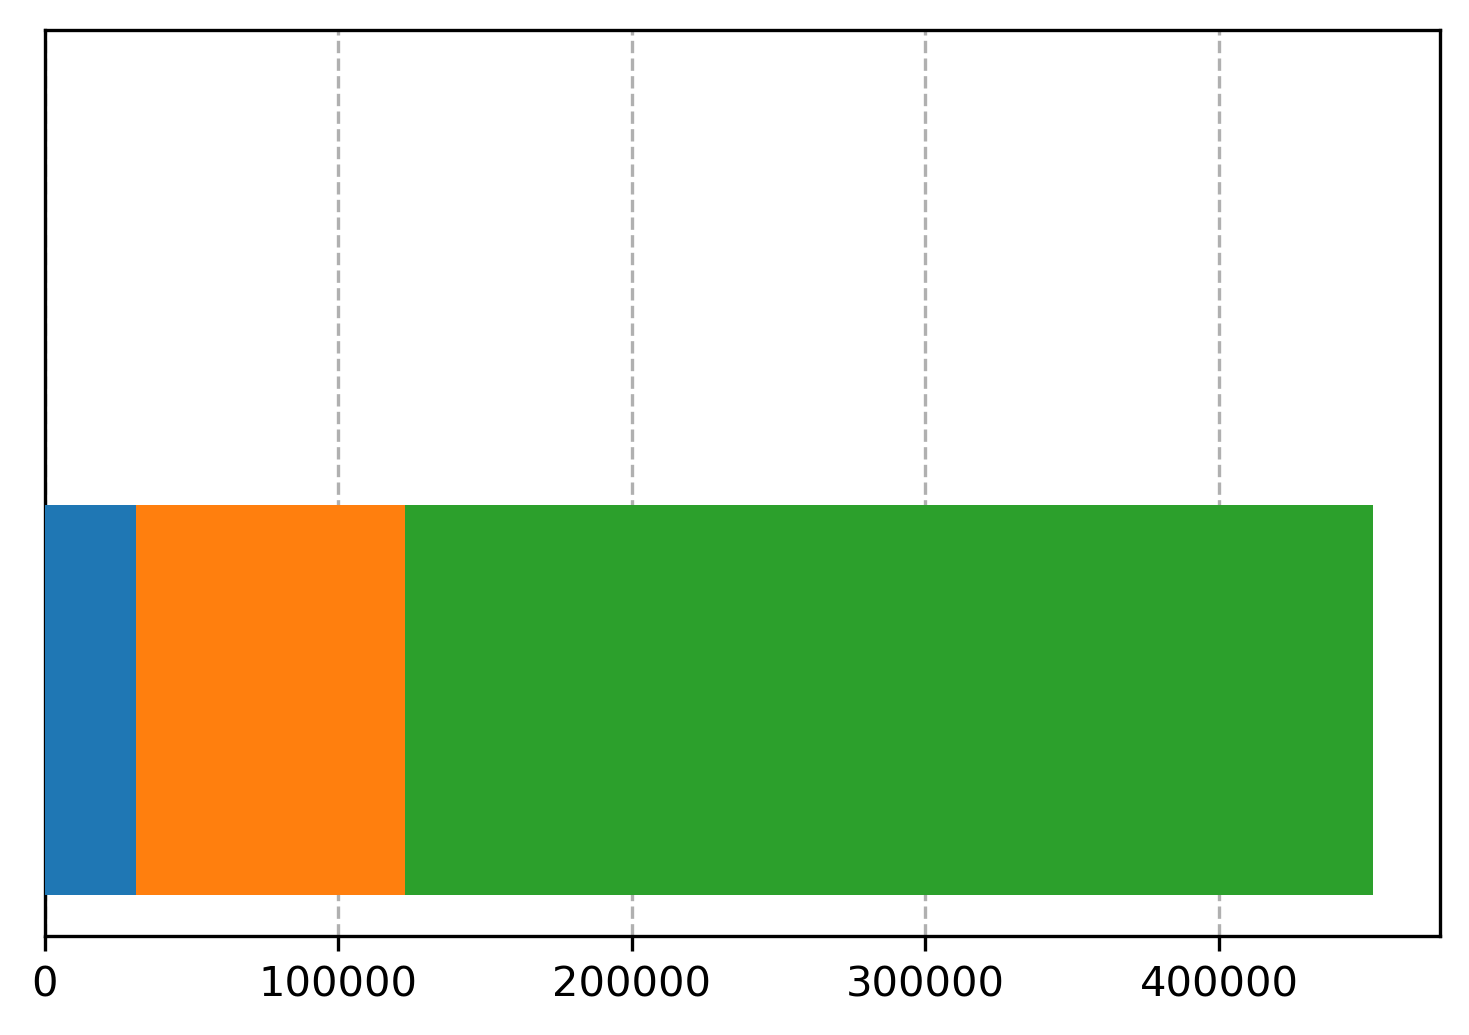

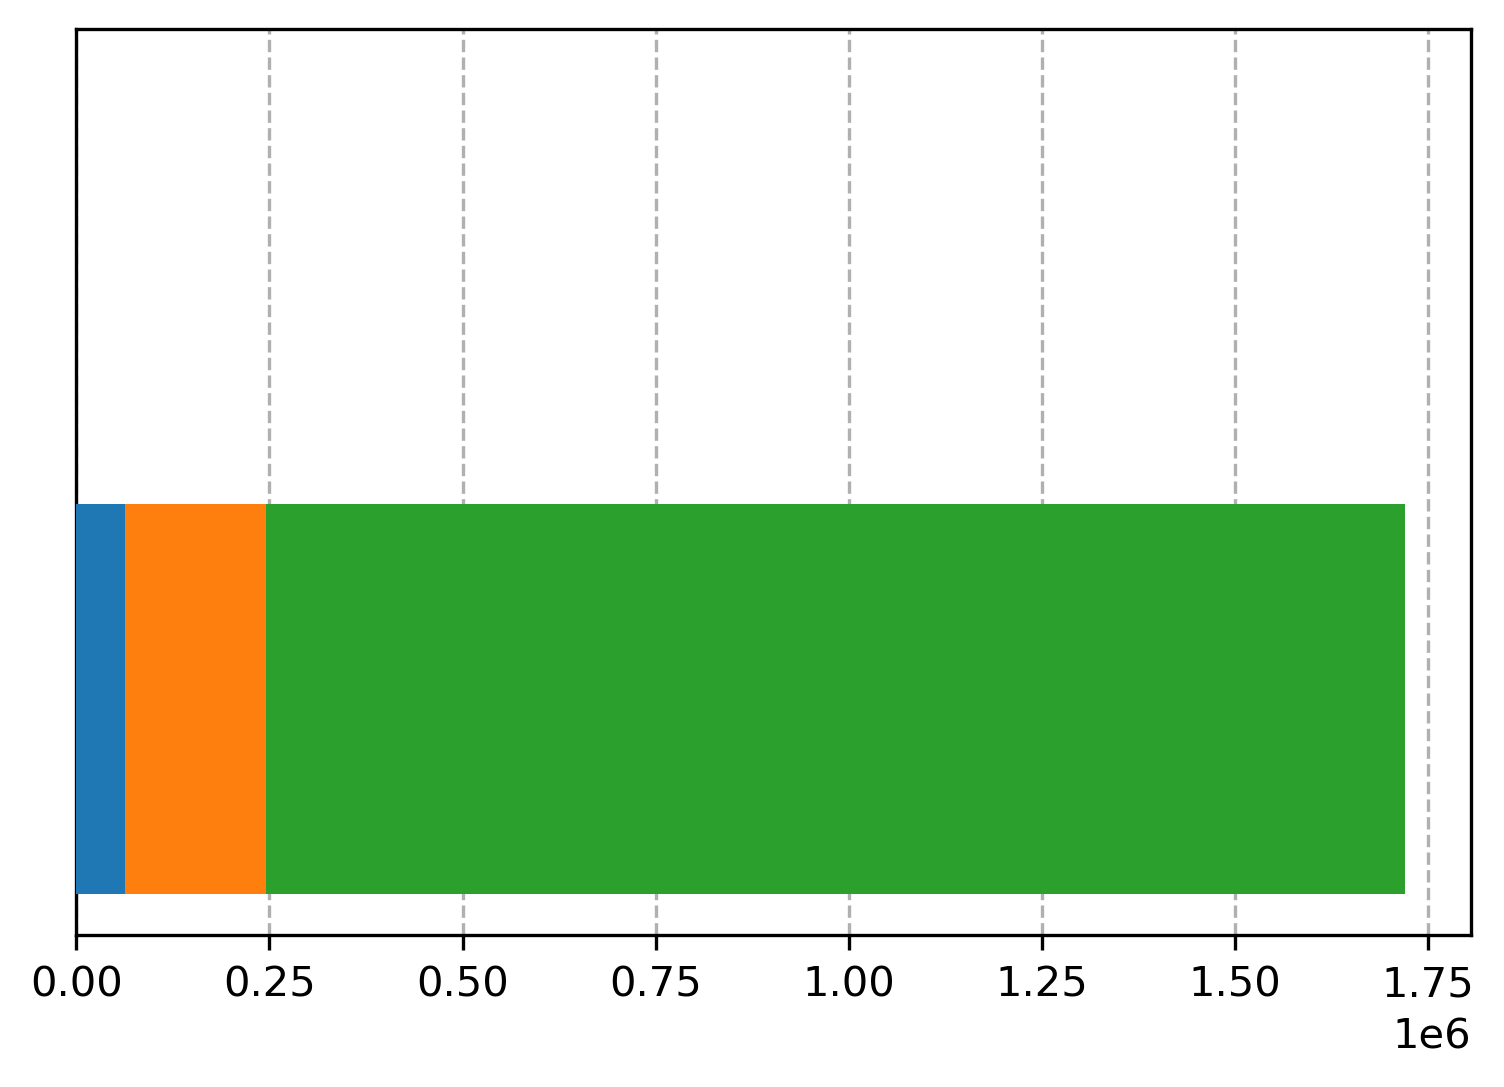

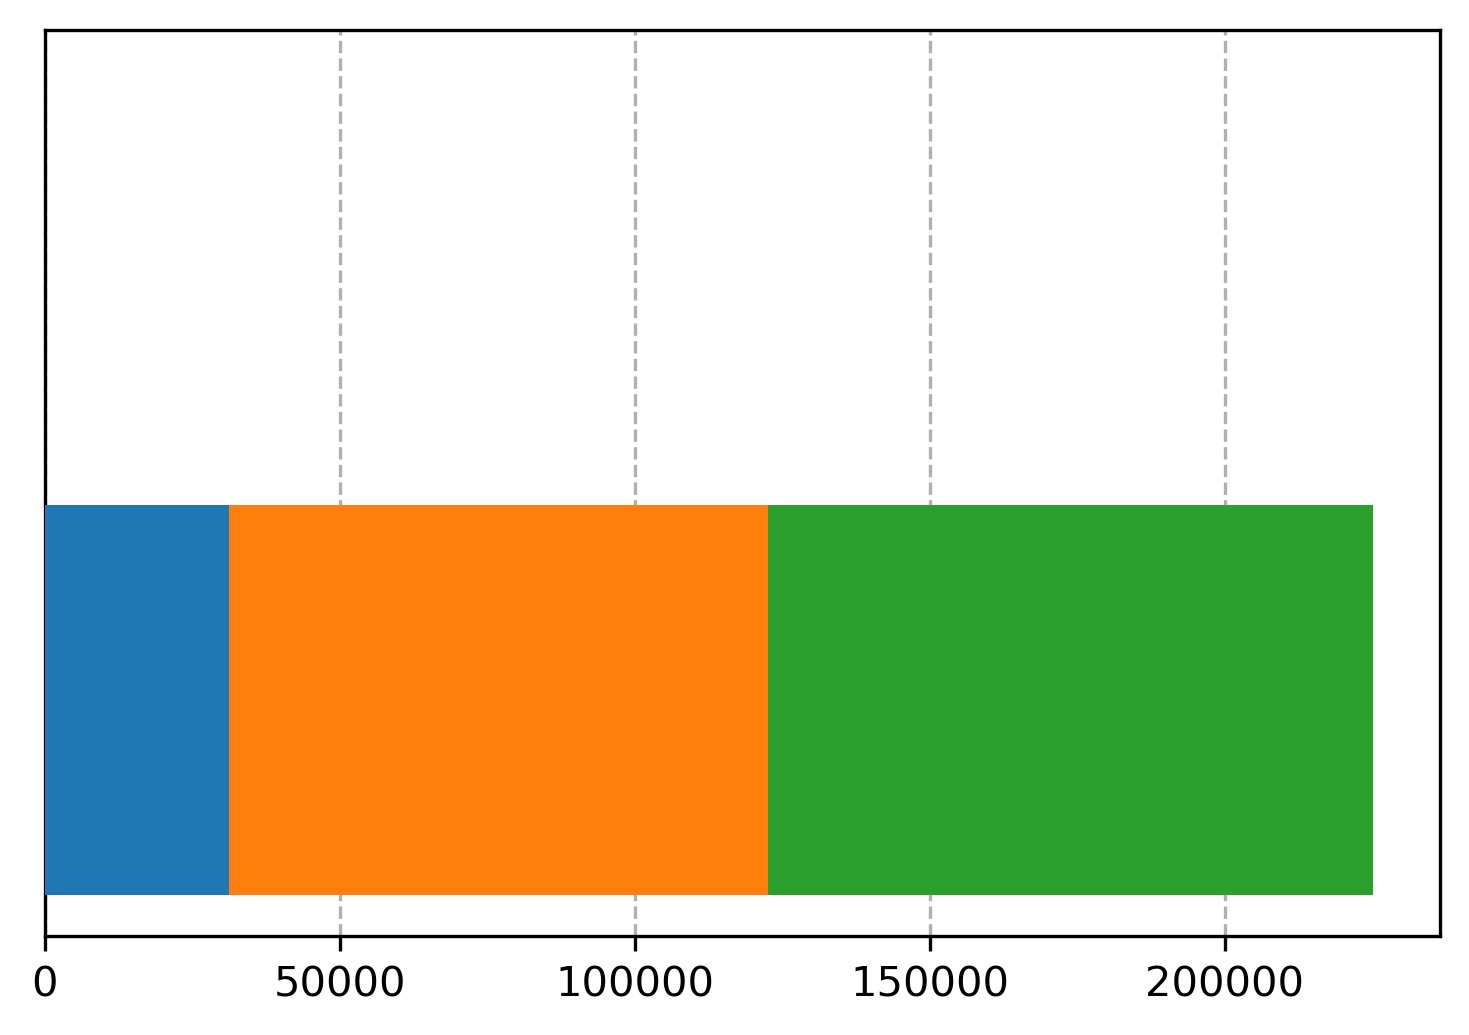

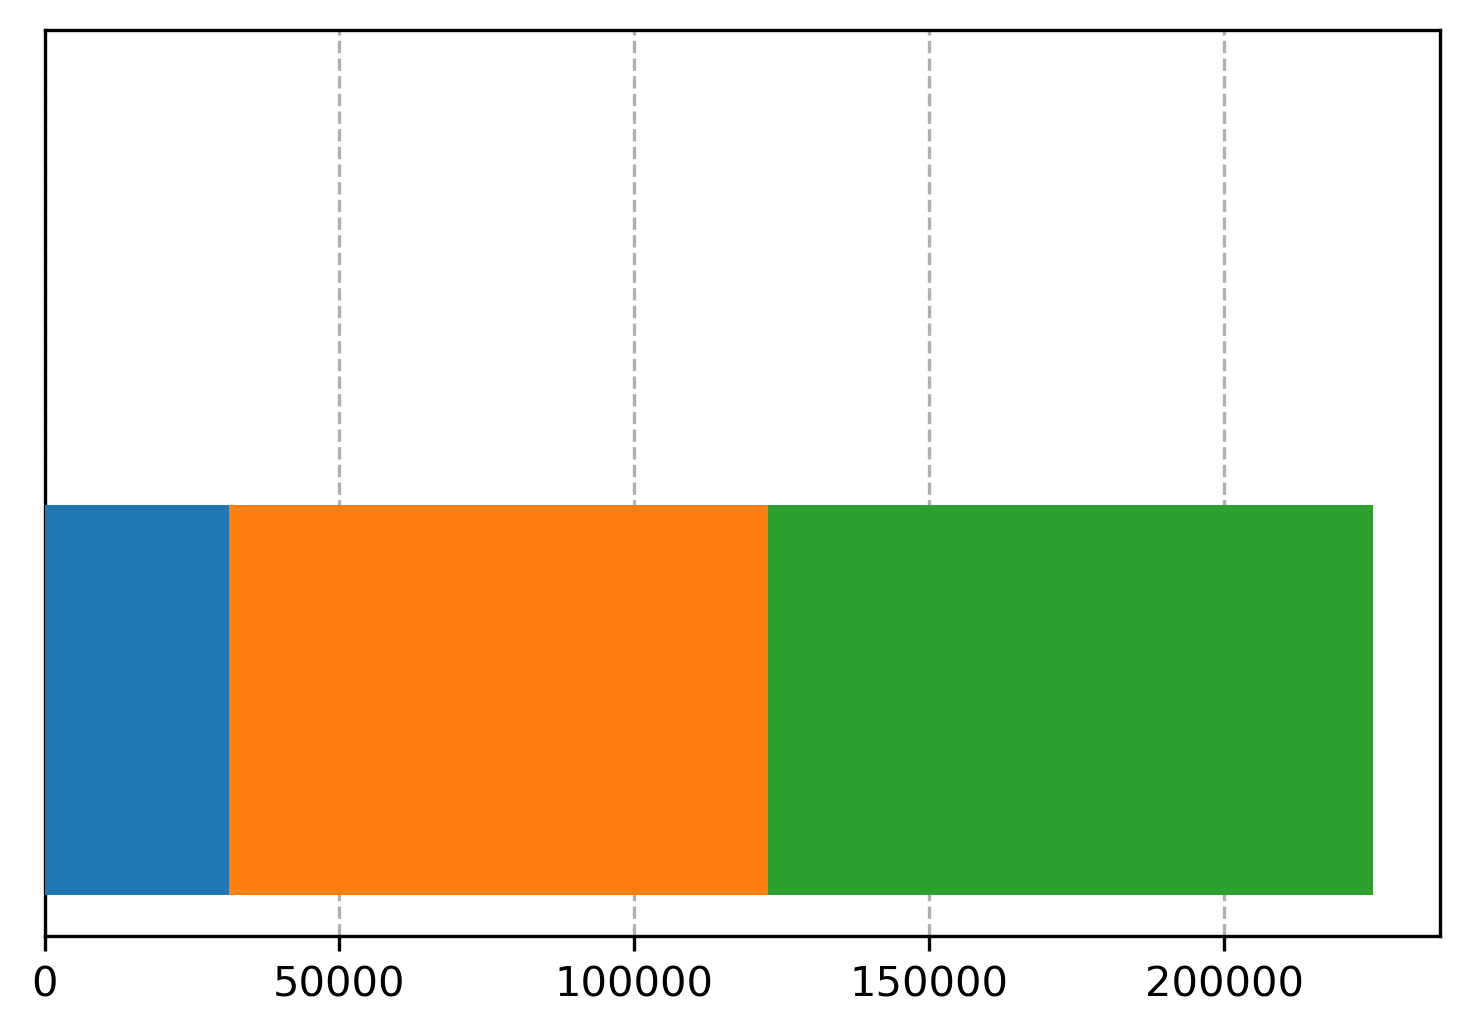

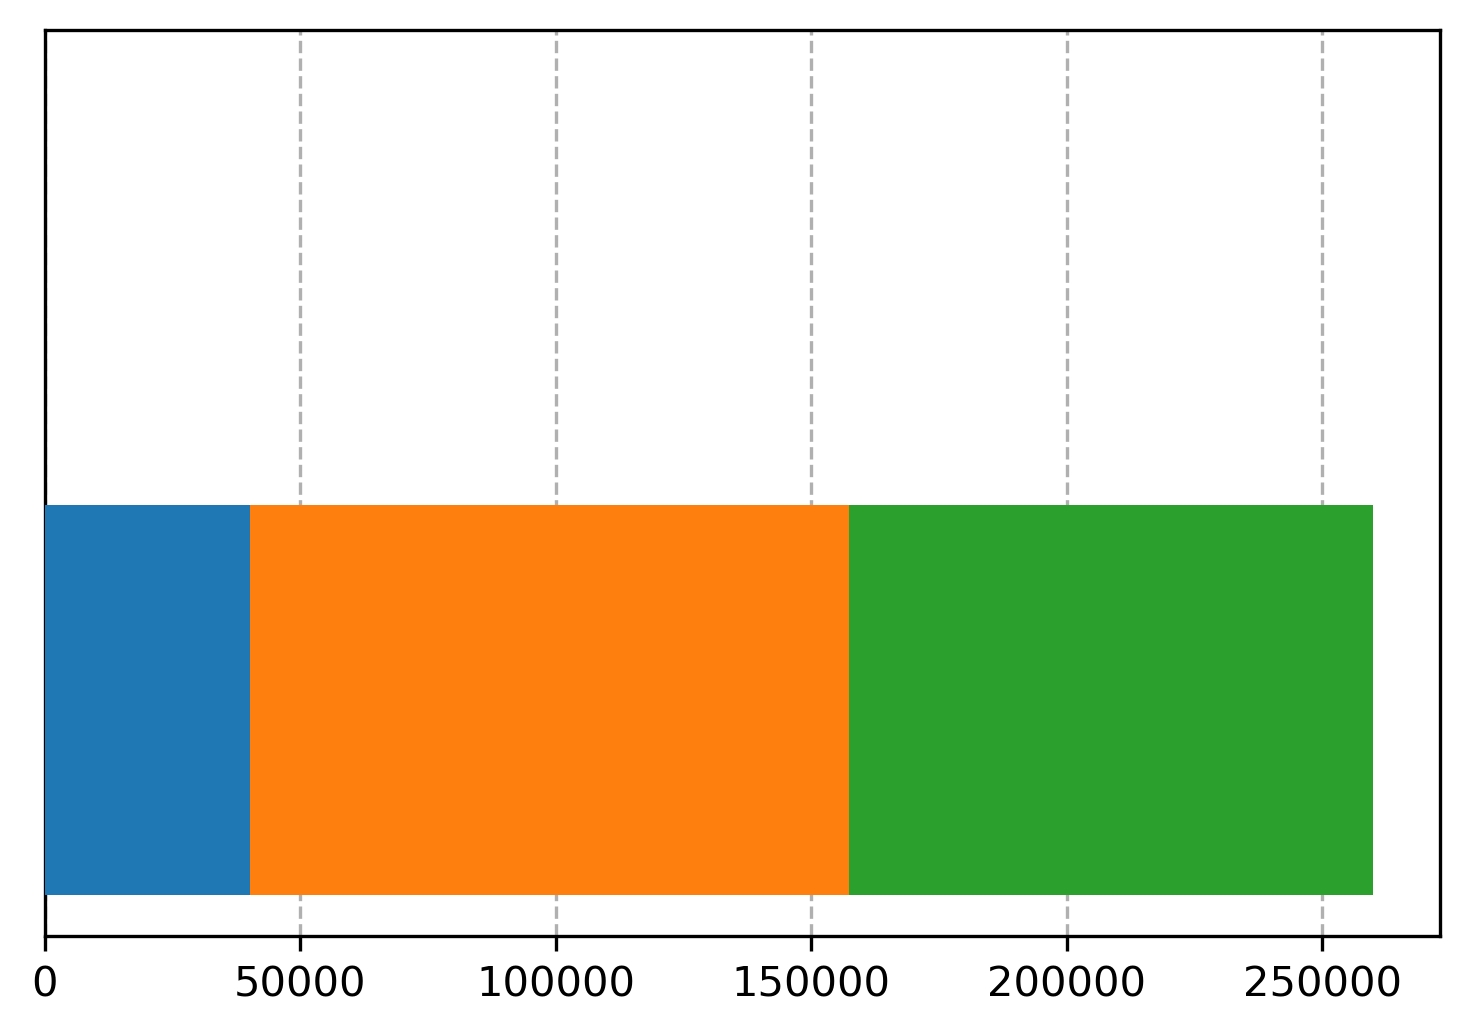

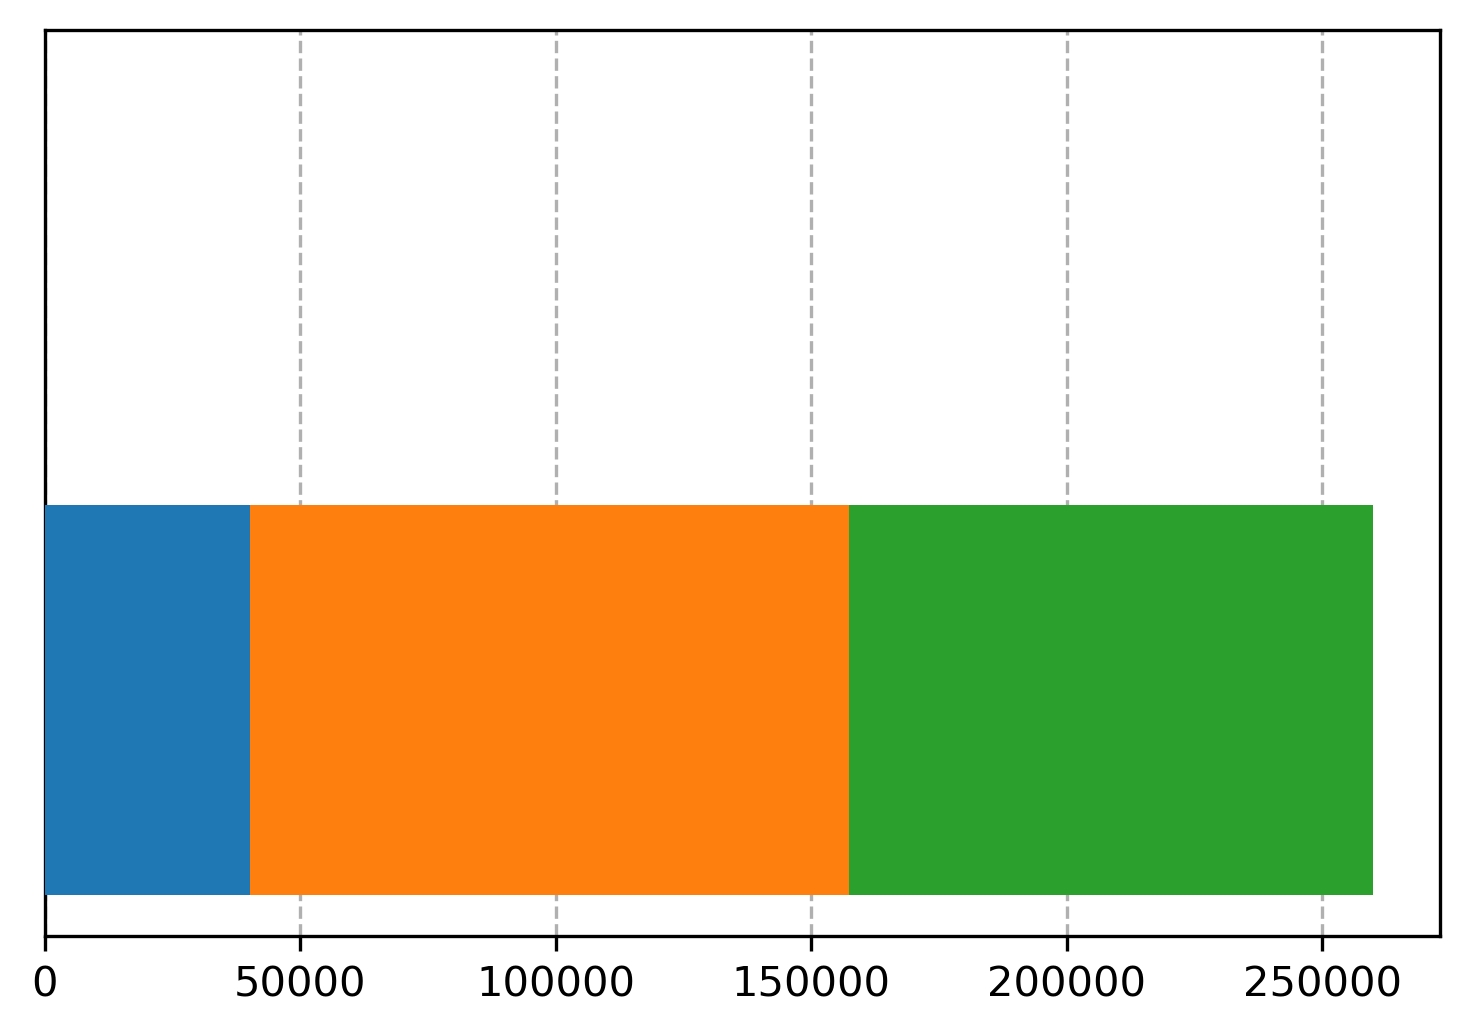

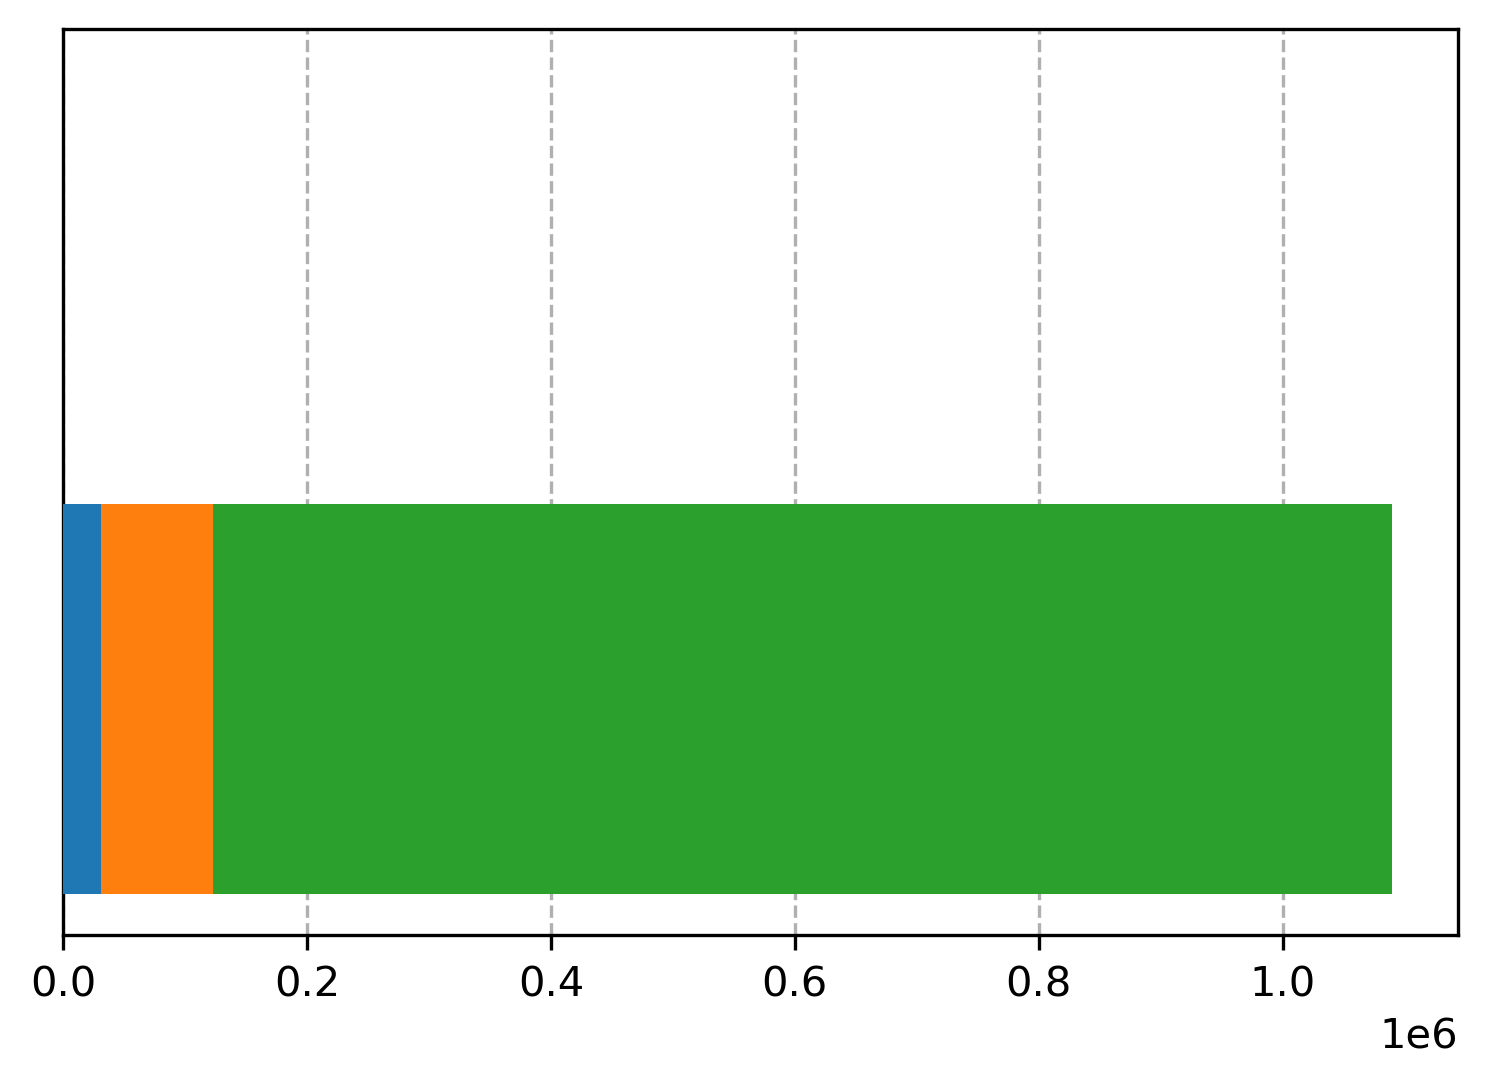

In [13]:
Require_Token_per_Second = 99000000
Hardware_Config = [
{# 8*A100
    "Config": "8*A100",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"A100", "quant":8}}],
    "Cost": {"A100":8, "Server": 1, "Rack_Unit": 4,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*A100 + 8*G6AiM
    "Config": "8*A100 + 8*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"G6AiM", "quant":8}}],
    "Cost": {"A100":8, "G6AiM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*A100 + 8*HBM-PIM
    "Config": "8*A100 + 8*HBM-PIM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"HBM-PIM-Board", "quant":8}}],
    "Cost": {"A100":8, "HBM-PIM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 4*A100 + 4*Upmem
    "Config": "4*A100 + 4*Upmem",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":4}, "GNR-PRJ":{"hard":"A100", "quant":4}, "GNR-ACT":{"hard":"Upmem", "quant":4}}],
    "Cost": {"A100":4, "Upmem":4, "Server": 5, "Rack_Unit": 12,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*A100 + 8*LPDDR4-PIM-DIMM
    "Config": "8*A100 + 8*LPDDR4-PIM-DIMM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"LPDDR4-PIM-DIMM", "quant":8}}],
    "Cost": {"A100":8, "LPDDR4-PIM-DIMM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*A100 + 32*LPDDR4-PIM-PCIe
    "Config": "8*A100 + 32*LPDDR4-PIM-PCIe",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"LPDDR4-PIM-PCIe", "quant":32}}],
    "Cost": {"A100":8, "LPDDR4-PIM-PCIe":32, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*THRIVE2 + 8*LPDDR4-PIM-DIMM
    "Config": "8*THRIVE2 + 8*LPDDR4-PIM-DIMM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"THRIVE2", "quant":8}, "GNR-PRJ":{"hard":"THRIVE2", "quant":8}, "GNR-ACT":{"hard":"LPDDR4-PIM-DIMM", "quant":8}}],
    "Cost": {"THRIVE2":8, "LPDDR4-PIM-DIMM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
{# 8*THRIVE4 + 8*LPDDR4-PIM-DIMM
    "Config": "8*THRIVE4 + 8*LPDDR4-PIM-DIMM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"THRIVE4", "quant":8}, "GNR-PRJ":{"hard":"THRIVE4", "quant":8}, "GNR-ACT":{"hard":"LPDDR4-PIM-DIMM", "quant":8}}],
    "Cost": {"THRIVE4":8, "LPDDR4-PIM-DIMM":8, "Server": 2, "Rack_Unit": 8,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
},
# {# 8*A100 + 853*SSD-PIM
#     "Config": "8*A100 + 853*SSD-PIM",
#     "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"SSD-PIM", "quant":853}}],
#     "Cost": {"A100":8, "SSD-PIM":853, "Server": 14, "Rack_Unit": 56,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 0}
# }
]

## Calculate Token per Sec from Han's roofline Model
roofline = TransformerRoofline('hardware_models.json')
for hw in Hardware_Config:
    roofline.Draw_Combination_Timebreakdown(Ratio_P=[0.25], Batchsize=[32], Max_Token=[8192], Model=["GPT3.5"], Comb_Hardware=hw["Roofline"], Sparse=["default"])
    hw["Cost"]["Token_per_Second"] = roofline.Token_per_Sec[0]

cost_model = CostEst(hardware_json="hardware_elements.json")
for hw in Hardware_Config:
    cost_model.init_hardware(hardware_config=hw["Cost"])
    cost_model.cal_total_cost()
    cost_model.List_Price_Breakdown(fig=False)
    if hw["Config"] == "8*A100":
        price_per_token_base = cost_model.price_per_token
    print("------------ Hardware config: {} -------------".format(hw["Config"]))
    print("Token per Sec: {}".format(hw["Cost"]["Token_per_Second"]))
    print("Price per Token: ￥{}".format(cost_model.price_per_token))
    print("Price per Token: ${}".format(cost_model.price_per_token/6.95))
    print("Ratio (/8*A100): {}".format(price_per_token_base/cost_model.price_per_token))
    print("XPU price: {:.1f}; PIM: {:.1f}".format(cost_model.XPU_price, cost_model.PIM_price))
    print("----------------------------------------------")


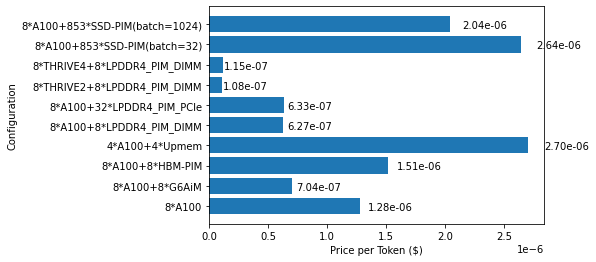

In [18]:
# config = ["OpenAI", "AWS(8*A100)","Aliyun(8*A100)","8*A100", "8*A100+8*G6AiM", "8*A100+8*HBM-PIM", "4*A100+4*Upmem", "8*A100+8*LPDDR4_PIM_DIMM", "8*A100+32*LPDDR4_PIM_PCIe","8*THRIVE2+8*LPDDR4_PIM_DIMM","8*THRIVE4+8*LPDDR4_PIM_DIMM", "8*A100+853*SSD-PIM(batch=32)", "8*A100+853*SSD-PIM(batch=1024)"]
# price = [4.5e-5, 1.96e-5, 1.53e-5, 1.28e-6, 7.04e-7, 1.51e-6, 2.70e-6, 6.27e-7, 6.33e-7, 1.08e-7, 1.15e-7, 2.64e-6, 2.04e-6]
# # improve = [0.028, 0.065, 0.084, 1.0, 1.82, 0.85, 0.47, 2.04, 2.02, 11.85, 11.10]

config = ["8*A100", "8*A100+8*G6AiM", "8*A100+8*HBM-PIM", "4*A100+4*Upmem", "8*A100+8*LPDDR4_PIM_DIMM", "8*A100+32*LPDDR4_PIM_PCIe","8*THRIVE2+8*LPDDR4_PIM_DIMM","8*THRIVE4+8*LPDDR4_PIM_DIMM", "8*A100+853*SSD-PIM(batch=32)", "8*A100+853*SSD-PIM(batch=1024)"]
price = [1.28e-6, 7.04e-7, 1.51e-6, 2.70e-6, 6.27e-7, 6.33e-7, 1.08e-7, 1.15e-7, 2.64e-6, 2.04e-6]
# improve = [1.0, 1.82, 0.85, 0.47, 2.04, 2.02, 11.85, 11.10]

plt.barh(config, price)

for index, y_value in enumerate(price):
    plt.text(y_value*1.05, index-0.2, "%.2e"%price[index])
# plt.xscale('log')
plt.xlabel("Price per Token ($)")
plt.ylabel("Configuration")
plt.show()


In [8]:
## A100+G6AiM calculation for Xuhan
Require_Token_per_Second = 99000000
Hardware_Config = [
{# Prefill:24*A100,GNR-PRF:24*A100,GNR-ACT:8*G6AiM
    "Config": "Prefill:24*A100,GNR-PRF:24*A100,GNR-ACT:8*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":24}, "GNR-PRJ":{"hard":"A100", "quant":24}, "GNR-ACT":{"hard":"G6AiM", "quant":8}}],
    "Cost": {"A100":24, "G6AiM":8, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 454}
},
{# Prefill:16*A100,GNR-PRF:16*A100,GNR-ACT:16*G6AiM
    "Config": "Prefill:16*A100,GNR-PRF:16*A100,GNR-ACT:16*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":16}, "GNR-PRJ":{"hard":"A100", "quant":16}, "GNR-ACT":{"hard":"G6AiM", "quant":16}}],
    "Cost": {"A100":16, "G6AiM":16, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 330}
},
{# Prefill:8*A100,GNR-PRF:8*A100,GNR-ACT:24*G6AiM
    "Config": "8*A100,GNR-PRF:8*A100,GNR-ACT:24*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"A100", "quant":8}, "GNR-ACT":{"hard":"G6AiM", "quant":24}}],
    "Cost": {"A100":8, "G6AiM":24, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 175}
},
{# Prefill:4*A100,GNR-PRF:28*G6AiM,GNR-ACT:28*G6AiM
    "Config": "4*A100,GNR-PRF:28*G6AiM,GNR-ACT:28*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":4}, "GNR-PRJ":{"hard":"G6AiM", "quant":28}, "GNR-ACT":{"hard":"G6AiM", "quant":28}}],
    "Cost": {"A100":4, "G6AiM":28, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 593}
},
{# Prefill:8*A100,GNR-PRF:24*G6AiM,GNR-ACT:24*G6AiM
    "Config": "8*A100,GNR-PRF:24*G6AiM,GNR-ACT:24*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":8}, "GNR-PRJ":{"hard":"G6AiM", "quant":24}, "GNR-ACT":{"hard":"G6AiM", "quant":24}}],
    "Cost": {"A100":8, "G6AiM":24, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 721}
},
{# Prefill:12*A100,GNR-PRF:20*G6AiM,GNR-ACT:20*G6AiM
    "Config": "12*A100,GNR-PRF:20*G6AiM,GNR-ACT:20*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":12}, "GNR-PRJ":{"hard":"G6AiM", "quant":20}, "GNR-ACT":{"hard":"G6AiM", "quant":20}}],
    "Cost": {"A100":12, "G6AiM":20, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 699}
},
{# Prefill:16*A100,GNR-PRF:16*G6AiM,GNR-ACT:16*G6AiM
    "Config": "16*A100,GNR-PRF:16*G6AiM,GNR-ACT:16*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":16}, "GNR-PRJ":{"hard":"G6AiM", "quant":16}, "GNR-ACT":{"hard":"G6AiM", "quant":16}}],
    "Cost": {"A100":16, "G6AiM":16, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 608}
},
{# Prefill:20*A100,GNR-PRF:12*G6AiM,GNR-ACT:12*G6AiM
    "Config": "20*A100,GNR-PRF:12*G6AiM,GNR-ACT:12*G6AiM",
    "Roofline": [{"Name":"1", "PRF":{"hard":"A100", "quant":20}, "GNR-PRJ":{"hard":"G6AiM", "quant":12}, "GNR-ACT":{"hard":"G6AiM", "quant":12}}],
    "Cost": {"A100":20, "G6AiM":12, "Server": 4, "Rack_Unit": 16,"Require_Token_per_Second": Require_Token_per_Second,"Token_per_Second": 482}
}
]


roofline = TransformerRoofline('hardware_models.json')
cost_model = CostEst(hardware_json="hardware_elements.json")

for hw in Hardware_Config:
    cost_model.init_hardware(hardware_config=hw["Cost"])
    cost_model.cal_total_cost()
    print("------------ Hardware config: {} -------------".format(hw["Config"]))
    print("Token per Sec: {}".format(hw["Cost"]["Token_per_Second"]))
    print("Price per Token: {}".format(cost_model.price_per_token))
    print("----------------------------------------------")


------------ Hardware config: Prefill:24*A100,GNR-PRF:24*A100,GNR-ACT:8*G6AiM -------------
Token per Sec: 454
Price per Token: 3.116049616864293e-05
----------------------------------------------
------------ Hardware config: Prefill:16*A100,GNR-PRF:16*A100,GNR-ACT:16*G6AiM -------------
Token per Sec: 330
Price per Token: 3.409032705836359e-05
----------------------------------------------
------------ Hardware config: 8*A100,GNR-PRF:8*A100,GNR-ACT:24*G6AiM -------------
Token per Sec: 175
Price per Token: 4.773000341689187e-05
----------------------------------------------
------------ Hardware config: 4*A100,GNR-PRF:28*G6AiM,GNR-ACT:28*G6AiM -------------
Token per Sec: 593
Price per Token: 1.164287003761235e-05
----------------------------------------------
------------ Hardware config: 8*A100,GNR-PRF:24*G6AiM,GNR-ACT:24*G6AiM -------------
Token per Sec: 721
Price per Token: 1.1584952285653366e-05
----------------------------------------------
------------ Hardware config: 12*A10